c:\Users\eriya\anaconda3\envs\python-env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26908 (\N{CJK UNIFIED IDEOGRAPH-691C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\eriya\anaconda3\envs\python-env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 35388 (\N{CJK UNIFIED IDEOGRAPH-8A3C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\eriya\anaconda3\envs\python-env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12487 (\N{KATAKANA LETTER DE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\eriya\anaconda3\envs\python-env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\eriya\anaconda3\envs\python-env\Lib\site-packages\IPython\core\pylabtools.py:170: UserW

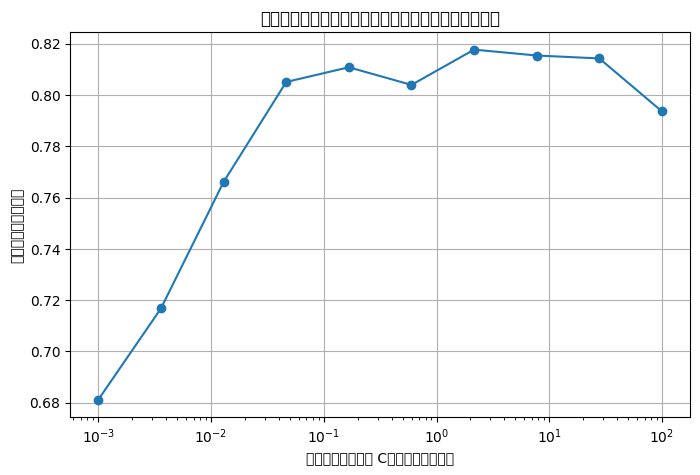

In [ ]:
import pandas as pd
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction import DictVectorizer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score

# --- データ読み込みとBoW変換 ---
def load_and_vectorize(filepath):
    df = pd.read_csv(filepath, sep='\t')
    data = []
    for _, row in df.iterrows():
        text = row['sentence']
        label = str(row['label'])
        tokens = text.split()
        feature = dict(Counter(tokens))
        data.append({'text': text, 'label': label, 'feature': feature})
    return data

# --- データの準備 ---
train_data = load_and_vectorize('train.tsv')
dev_data = load_and_vectorize('dev.tsv')

X_train = [d['feature'] for d in train_data]
y_train = [int(d['label']) for d in train_data]
X_dev = [d['feature'] for d in dev_data]
y_dev = [int(d['label']) for d in dev_data]

# --- 正則化パラメータのリスト（対数スケール） ---
C_values = np.logspace(-3, 2, 10)  # 0.001 ~ 100
accuracies = []

# --- 各 C に対してモデルを学習・評価 ---
for C in C_values:
    model = make_pipeline(DictVectorizer(), LogisticRegression(C=C, max_iter=1000))
    model.fit(X_train, y_train)
    y_pred = model.predict(X_dev)
    acc = accuracy_score(y_dev, y_pred)
    accuracies.append(acc)

# --- グラフの描画 ---
plt.figure(figsize=(8, 5))
plt.plot(C_values, accuracies, marker='o')
plt.xscale('log')
plt.xlabel('正則化パラメータ C（対数スケール）')
plt.ylabel('検証データの正解率')
plt.title('ロジスティック回帰における正則化パラメータと精度')
plt.grid(True)
plt.show()
